# Dataset Curation Notebook (Improve Label Quality Before Training)

This notebook creates a **curated training metadata dataset** from the initial sampled Spotify data, with explicit filtering for:
- duplicate rows / duplicate tracks,
- cross-genre label conflicts,
- model-ambiguous tracks,
- embedding outliers.

Outputs:
- curated metadata CSV (`data/processed/metadata_curated.csv`)
- curated grouped splits (`data/splits/curated/{train,val,test}.csv`)
- curation report JSON (`data/curation/curation_report.json`)


## How This Helps F1

Improving data quality often helps more than adding model complexity. This curation pass targets failure modes that lower macro F1:
- inconsistent labels for the same song,
- duplicate near-clones dominating specific classes,
- genre-bending tracks that act like label noise,
- extreme outliers in embedding space.

Keep this notebook conservative first (small removals), then tighten thresholds only if validation improves.


In [11]:
from pathlib import Path
import json
import re
import unicodedata

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

from src.data.clean_metadata import clean_metadata
from src.data.make_splits import make_splits
from src.models.evaluate import (
    load_embeddings,
    build_track_level_audio_eval_df,
    audio_probs_for_track_ids,
    _load_audio_preprocessor,
)
from src.models.train import get_metadata_X

sns.set_style('whitegrid')

from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler

## Configuration

In [12]:
PROJECT_ROOT = Path('.').resolve()

# Input data
SOURCE_CSV = PROJECT_ROOT / 'sampled_spotify_tracks_with_paths.csv'

# Working/output paths
WORK_DIR = PROJECT_ROOT / 'data' / 'curation'
PRE_CURATED_CSV = WORK_DIR / 'metadata_pre_curated.csv'
CURATED_CSV = PROJECT_ROOT / 'data' / 'processed' / 'metadata_curated.csv'
CURATED_SPLITS_DIR = PROJECT_ROOT / 'data' / 'splits' / 'curated'
CURATION_REPORT_JSON = WORK_DIR / 'curation_report.json'

# Optional Discogs enrichment (requires DISCOGS_USER_TOKEN)
RUN_DISCOGS_ENRICHMENT = False
DISCOGS_DELAY_SEC = 1.0
DISCOGS_OUT_CSV = WORK_DIR / 'metadata_discogs_enriched.csv'

# Optional model artefacts for ambiguity filtering
MODEL_DIR = PROJECT_ROOT / 'models' / 'full_run'
EMBEDDINGS_NPZ = PROJECT_ROOT / 'data' / 'processed' / 'embeddings' / 'audio_embeddings_windows.npz'
PROB_MODE = 'fusion'  # metadata|audio|fusion|audio_fusion
METADATA_CLASSIFIER = 'lightgbm'
AUDIO_CLASSIFIER = 'mlp'
AUDIO_FUSION_CLASSIFIER_A = 'logreg'
AUDIO_FUSION_CLASSIFIER_B = 'mlp'

# Duplicate/conflict filters
DROP_TRACK_ID_CONFLICTS = True
DROP_TITLE_ARTIST_GENRE_CONFLICTS = True
DROP_FILE_HASH_DUPLICATES = True
KEEP_HIGHEST_POPULARITY_ON_DUPLICATE = True

# Artist over-representation cap (0 disables)
MAX_TRACKS_PER_ARTIST_PER_GENRE = 20

# Ambiguity filter thresholds
USE_MODEL_AMBIGUITY_FILTER = True
AMBIGUITY_MARGIN_MAX = 0.08
AMBIGUITY_ENTROPY_MIN = 0.65
AMBIGUITY_ONLY_IF_WRONG = False

# Embedding outlier filter threshold
USE_EMBEDDING_OUTLIER_FILTER = True
OUTLIER_DISTANCE_QUANTILE = 0.995


# Confident learning (label-noise detection)
USE_CONFIDENT_LEARNING_FILTER = True
CL_USE_CLEANLAB_IF_AVAILABLE = True
CL_N_FOLDS = 5
CL_FLAG_FRACTION = 0.03
CL_ONLY_IF_PRED_DIFFERS = True

# Open-set filtering (tracks far from all genre manifolds)
USE_OPEN_SET_FILTER = True
OPEN_SET_SIMILARITY_QUANTILE = 0.01
OPEN_SET_MIN_GENRE_COUNT = 5

# Final clean_metadata controls
MIN_GENRE_COUNT = 120
MAX_GENRES = 10
DROP_GENRES = []
MAX_SAMPLES_PER_GENRE = 800
SEED = 42
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15

WORK_DIR.mkdir(parents=True, exist_ok=True)
CURATED_CSV.parent.mkdir(parents=True, exist_ok=True)
CURATED_SPLITS_DIR.mkdir(parents=True, exist_ok=True)

{
    'source_csv_exists': SOURCE_CSV.exists(),
    'embeddings_exists': EMBEDDINGS_NPZ.exists(),
    'model_dir_exists': MODEL_DIR.exists(),
    'prob_mode': PROB_MODE,
    'use_confident_learning_filter': USE_CONFIDENT_LEARNING_FILTER,
    'cl_use_cleanlab_if_available': CL_USE_CLEANLAB_IF_AVAILABLE,
    'use_open_set_filter': USE_OPEN_SET_FILTER,
    'open_set_similarity_quantile': OPEN_SET_SIMILARITY_QUANTILE,
    'curated_csv': str(CURATED_CSV),
    'curated_splits_dir': str(CURATED_SPLITS_DIR),
}


{'source_csv_exists': True,
 'embeddings_exists': True,
 'model_dir_exists': True,
 'prob_mode': 'fusion',
 'use_confident_learning_filter': True,
 'cl_use_cleanlab_if_available': True,
 'use_open_set_filter': True,
 'open_set_similarity_quantile': 0.01,
 'curated_csv': '/Volumes/MZ Music\uf028/genre-classifier/data/processed/metadata_curated.csv',
 'curated_splits_dir': '/Volumes/MZ Music\uf028/genre-classifier/data/splits/curated'}

## Step 1: Load and Canonicalize Base Dataset

In [13]:
def _primary_artist(value: str) -> str:
    if pd.isna(value):
        return ''
    return re.split(r'\s*;\s*', str(value).strip(), maxsplit=1)[0].strip()


def _norm_text(x: str) -> str:
    if pd.isna(x):
        return ''
    x = str(x).lower().strip()
    x = unicodedata.normalize('NFKD', x)
    x = re.sub(r'[^\w\s]', ' ', x)
    return re.sub(r'\s+', ' ', x).strip()


def load_base_dataset(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)
    unnamed = [c for c in df.columns if c.startswith('Unnamed:')]
    if unnamed:
        df = df.drop(columns=unnamed)

    # Canonical schema expected by downstream pipeline
    if 'track_genre' in df.columns and 'genre' not in df.columns:
        df['genre'] = df['track_genre']
    if 'artists' in df.columns and 'artist' not in df.columns:
        df['artist'] = df['artists'].apply(_primary_artist)
    if 'track_name' in df.columns and 'title' not in df.columns:
        df['title'] = df['track_name']
    if 'album_name' in df.columns and 'album' not in df.columns:
        df['album'] = df['album_name']

    required = ['track_id', 'artist', 'title', 'genre']
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise RuntimeError(f'Missing required columns in source CSV: {missing}')

    df['genre'] = df['genre'].astype(str).str.strip().str.lower()
    df['artist'] = df['artist'].astype(str).str.strip()
    df['title'] = df['title'].astype(str).str.strip()

    df['artist_norm'] = df['artist'].apply(_norm_text)
    df['title_norm'] = df['title'].apply(_norm_text)
    df['artist_title_key'] = df['artist_norm'] + '||' + df['title_norm']

    if 'popularity' in df.columns:
        df['popularity'] = pd.to_numeric(df['popularity'], errors='coerce')
    else:
        df['popularity'] = np.nan

    return df.reset_index(drop=True)


base_df = load_base_dataset(SOURCE_CSV)

print(f'Loaded rows: {len(base_df):,}')
print(f'Unique track_id: {base_df["track_id"].nunique():,}')
print(f'Unique artist-title keys: {base_df["artist_title_key"].nunique():,}')
print(f'Genres: {base_df["genre"].nunique()}')
print('Top genres:')
display(base_df['genre'].value_counts().head(15).to_frame('count'))


Loaded rows: 3,600
Unique track_id: 3,511
Unique artist-title keys: 2,876
Genres: 8
Top genres:


,count
genre,
electronic,450
pop,450
indie,450
rock,450
folk,450
metal,450
classical,450
jazz,450


## Step 1b (Optional): Discogs Enrichment

In [14]:
if RUN_DISCOGS_ENRICHMENT:
    from src.data.fetch_discogs import enrich_with_discogs

    discogs_df = enrich_with_discogs(
        in_csv=str(SOURCE_CSV),
        out_csv=str(DISCOGS_OUT_CSV),
        delay=float(DISCOGS_DELAY_SEC),
    )
    print('Discogs enrichment saved ->', DISCOGS_OUT_CSV)
    print('Discogs match rate:', round(float(discogs_df['discogs_genres'].notna().mean()), 4))
else:
    print('RUN_DISCOGS_ENRICHMENT=False -> skipping Discogs API pass.')


RUN_DISCOGS_ENRICHMENT=False -> skipping Discogs API pass.


## Step 2: Identify Duplicates and Label Conflicts

In [15]:
dup_track_id_counts = base_df['track_id'].value_counts()
dup_track_ids = dup_track_id_counts[dup_track_id_counts > 1].index

dup_artist_title_counts = base_df['artist_title_key'].value_counts()
dup_artist_title_keys = dup_artist_title_counts[dup_artist_title_counts > 1].index

conflict_track_ids = (
    base_df.groupby('track_id')['genre'].nunique().loc[lambda s: s > 1].index
)
conflict_artist_title_keys = (
    base_df.groupby('artist_title_key')['genre'].nunique().loc[lambda s: s > 1].index
)

if 'file_sha256' in base_df.columns:
    hash_counts = base_df['file_sha256'].dropna().value_counts()
    duplicate_hashes = hash_counts[hash_counts > 1].index
else:
    duplicate_hashes = []

summary = {
    'duplicate_track_id_groups': int(len(dup_track_ids)),
    'duplicate_artist_title_groups': int(len(dup_artist_title_keys)),
    'conflicting_track_id_groups': int(len(conflict_track_ids)),
    'conflicting_artist_title_groups': int(len(conflict_artist_title_keys)),
    'duplicate_file_hash_groups': int(len(duplicate_hashes)),
}
summary


{'duplicate_track_id_groups': 89,
 'duplicate_artist_title_groups': 343,
 'conflicting_track_id_groups': 71,
 'conflicting_artist_title_groups': 77,
 'duplicate_file_hash_groups': 337}

In [16]:
print('Examples: conflicting track_id labels')
if len(conflict_track_ids) > 0:
    display(
        base_df[base_df['track_id'].isin(conflict_track_ids)]
        .sort_values(['track_id', 'genre'])
        [['track_id', 'artist', 'title', 'genre', 'popularity']]
        .head(40)
    )
else:
    print('None')

print('\nExamples: conflicting artist-title labels')
if len(conflict_artist_title_keys) > 0:
    display(
        base_df[base_df['artist_title_key'].isin(conflict_artist_title_keys)]
        .sort_values(['artist_title_key', 'genre'])
        [['track_id', 'artist', 'title', 'genre', 'popularity']]
        .head(40)
    )
else:
    print('None')


Examples: conflicting track_id labels


,track_id,artist,title,genre,popularity
2525,06Stw5UCrKYwPBxsTOfBtA,Ghost,Mary On A Cross,metal,0
1413,06Stw5UCrKYwPBxsTOfBtA,Ghost,Mary On A Cross,rock,0
1093,0FrFqoPT7JB0ezIU9g2OLC,Deftones,Ohms,indie,0
2327,0FrFqoPT7JB0ezIU9g2OLC,Deftones,Ohms,metal,0
3125,0Hk2PNJ4Ac4q9g72MSoqi7,Dream Theater,Under a Glass Moon,classical,0
2576,0Hk2PNJ4Ac4q9g72MSoqi7,Dream Theater,Under a Glass Moon,metal,0
2593,0LvONfXemxF8eUKovfhZdH,Skillet,Feel Invincible,metal,0
1382,0LvONfXemxF8eUKovfhZdH,Skillet,Feel Invincible,rock,0
2624,0LxGFgMi5Bv6q3vJ0aCnRX,Ghost,Mary On A Cross,metal,5
1634,0LxGFgMi5Bv6q3vJ0aCnRX,Ghost,Mary On A Cross,rock,5



Examples: conflicting artist-title labels


,track_id,artist,title,genre,popularity
1810,4lRuRtvftdSSUA7hLP7zAr,Amber Run,I Found,folk,60
1064,5zT5cMnMKoyruPj13TQXGx,Amber Run,I Found,indie,74
1035,5FVd6KXrgO9B3JPmC8OPst,Arctic Monkeys,Do I Wanna Know?,indie,88
1376,5FVd6KXrgO9B3JPmC8OPst,Arctic Monkeys,Do I Wanna Know?,rock,88
1332,2AT8iROs4FQueDv2c8q2KE,Arctic Monkeys,R U Mine?,indie,83
1441,2AT8iROs4FQueDv2c8q2KE,Arctic Monkeys,R U Mine?,rock,83
223,34kHexFdmug6nYZzkz3hc0,Babasónicos,Como Eran Las Cosas,electronic,0
1504,6FvZIDTCtmWC4KERBlLQ5f,Babasónicos,Como Eran Las Cosas,rock,0
1655,34kHexFdmug6nYZzkz3hc0,Babasónicos,Como Eran Las Cosas,rock,0
1071,14BH4qO7pgCmIe6mgLKOK3,BANNERS,Someone To You,indie,73


## Step 3: Model-Aware Ambiguity Scoring (Optional)

In [17]:
analysis_scores = pd.DataFrame(columns=['track_id', 'confidence', 'top2_margin', 'entropy_norm', 'correct'])

can_score = (
    USE_MODEL_AMBIGUITY_FILTER
    and MODEL_DIR.exists()
    and EMBEDDINGS_NPZ.exists()
    and (MODEL_DIR / 'label_encoder.joblib').exists()
)

if can_score:
    le = joblib.load(MODEL_DIR / 'label_encoder.joblib')
    known = set(le.classes_)

    id_to_indices, embeddings = load_embeddings(str(EMBEDDINGS_NPZ))
    eval_df = build_track_level_audio_eval_df(base_df, known, set(id_to_indices))

    if len(eval_df) == 0:
        print('No rows available for model scoring after known-genre + embedding filtering.')
    else:
        y_true = le.transform(eval_df['genre'])

        if PROB_MODE == 'audio':
            audio_model = joblib.load(MODEL_DIR / f'audio_{AUDIO_CLASSIFIER}.joblib')
            audio_preproc = _load_audio_preprocessor(MODEL_DIR, AUDIO_CLASSIFIER)
            prob = audio_probs_for_track_ids(
                eval_df['track_id'], id_to_indices, embeddings, audio_model, audio_preprocessor=audio_preproc
            )

        elif PROB_MODE == 'fusion':
            scaler = joblib.load(MODEL_DIR / 'metadata_scaler.joblib')
            feature_cols = joblib.load(MODEL_DIR / 'metadata_feature_cols.joblib')
            train_medians = joblib.load(MODEL_DIR / 'metadata_train_medians.joblib')
            meta_model = joblib.load(MODEL_DIR / f'metadata_{METADATA_CLASSIFIER}.joblib')
            audio_model = joblib.load(MODEL_DIR / f'audio_{AUDIO_CLASSIFIER}.joblib')
            audio_preproc = _load_audio_preprocessor(MODEL_DIR, AUDIO_CLASSIFIER)

            X_meta_raw = get_metadata_X(eval_df, feature_cols)
            X_meta = scaler.transform(X_meta_raw.fillna(train_medians).fillna(0.0))
            prob_meta = meta_model.predict_proba(X_meta)
            prob_audio = audio_probs_for_track_ids(
                eval_df['track_id'], id_to_indices, embeddings, audio_model, audio_preprocessor=audio_preproc
            )

            weight_path = MODEL_DIR / f'fusion_weights_meta-{METADATA_CLASSIFIER}_audio-{AUDIO_CLASSIFIER}.joblib'
            if weight_path.exists():
                payload = joblib.load(weight_path)
                w_meta = float(payload.get('weight_meta', 0.5))
            else:
                w_meta = 0.5
            prob = w_meta * prob_meta + (1.0 - w_meta) * prob_audio

        elif PROB_MODE == 'audio_fusion':
            model_a = joblib.load(MODEL_DIR / f'audio_{AUDIO_FUSION_CLASSIFIER_A}.joblib')
            model_b = joblib.load(MODEL_DIR / f'audio_{AUDIO_FUSION_CLASSIFIER_B}.joblib')
            pre_a = _load_audio_preprocessor(MODEL_DIR, AUDIO_FUSION_CLASSIFIER_A)
            pre_b = _load_audio_preprocessor(MODEL_DIR, AUDIO_FUSION_CLASSIFIER_B)

            prob_a = audio_probs_for_track_ids(
                eval_df['track_id'], id_to_indices, embeddings, model_a, audio_preprocessor=pre_a
            )
            prob_b = audio_probs_for_track_ids(
                eval_df['track_id'], id_to_indices, embeddings, model_b, audio_preprocessor=pre_b
            )

            weight_path = MODEL_DIR / (
                f'audio_fusion_weights_audioA-{AUDIO_FUSION_CLASSIFIER_A}_audioB-{AUDIO_FUSION_CLASSIFIER_B}.joblib'
            )
            if weight_path.exists():
                payload = joblib.load(weight_path)
                w_a = float(payload.get('weight_a', 0.5))
            else:
                w_a = 0.5
            prob = w_a * prob_a + (1.0 - w_a) * prob_b

        elif PROB_MODE == 'metadata':
            scaler = joblib.load(MODEL_DIR / 'metadata_scaler.joblib')
            feature_cols = joblib.load(MODEL_DIR / 'metadata_feature_cols.joblib')
            train_medians = joblib.load(MODEL_DIR / 'metadata_train_medians.joblib')
            meta_model = joblib.load(MODEL_DIR / f'metadata_{METADATA_CLASSIFIER}.joblib')
            X_meta_raw = get_metadata_X(eval_df, feature_cols)
            X_meta = scaler.transform(X_meta_raw.fillna(train_medians).fillna(0.0))
            prob = meta_model.predict_proba(X_meta)

        else:
            raise ValueError("PROB_MODE must be one of: metadata|audio|fusion|audio_fusion")

        sorted_idx = np.argsort(prob, axis=1)
        top1 = sorted_idx[:, -1]
        top2 = sorted_idx[:, -2]
        confidence = prob[np.arange(len(prob)), top1]
        second = prob[np.arange(len(prob)), top2]
        margin = confidence - second
        entropy = -np.sum(prob * np.log(np.clip(prob, 1e-12, 1.0)), axis=1) / np.log(prob.shape[1])

        analysis_scores = pd.DataFrame({
            'track_id': eval_df['track_id'].astype(str).values,
            'confidence': confidence,
            'top2_margin': margin,
            'entropy_norm': entropy,
            'correct': top1 == y_true,
        })

        print(f'Model-scored rows: {len(analysis_scores):,}')
        print('Median top2 margin:', round(float(np.median(margin)), 4))
        print('Median entropy:', round(float(np.median(entropy)), 4))
else:
    print('Skipping model ambiguity scoring (missing artefacts or disabled).')

base_scored_df = base_df.merge(analysis_scores, on='track_id', how='left')


Model-scored rows: 2,684
Median top2 margin: 0.6905
Median entropy: 0.3887


In [18]:
if len(analysis_scores) > 0:
    ambig_mask = (
        (base_scored_df['top2_margin'] <= AMBIGUITY_MARGIN_MAX)
        & (base_scored_df['entropy_norm'] >= AMBIGUITY_ENTROPY_MIN)
    )
    if AMBIGUITY_ONLY_IF_WRONG:
        ambig_mask = ambig_mask & (base_scored_df['correct'] == False)

    print('Flagged ambiguous rows:', int(ambig_mask.fillna(False).sum()))

    cols = [
        'track_id', 'artist', 'title', 'genre',
        'confidence', 'top2_margin', 'entropy_norm', 'correct'
    ]
    display(
        base_scored_df.loc[ambig_mask.fillna(False), cols]
        .sort_values(['top2_margin', 'confidence'], ascending=[True, True])
        .head(25)
    )
else:
    print('No model-scored rows to inspect.')


Flagged ambiguous rows: 126


,track_id,artist,title,genre,confidence,top2_margin,entropy_norm,correct
2138,3Vby4nGmtbDo7HDJamOWkT,Stealers Wheel,Stuck In The Middle With You,folk,0.291167,0.000641,0.766581,True
1731,22Q68uXoySffMDUAzYUyLR,George Strait,O Christmas Tree,rock,0.325766,0.000688,0.762000,False
2224,0TAGwi2JsXjxebn1lW2qXP,Nusrat Fateh Ali Khan,Kinna Sohna Tenu,folk,0.288742,0.001085,0.853509,False
458,3LOVW8lNXFD9ZAUDvLIOR5,Atif Aslam,Tera Naam Doon (Lofi Mix),pop,0.204740,0.001249,0.910118,False
3305,16qiNIVuTP48hap3zT7txG,Dean Martin,Rudolph The Red-Nosed Reindeer,jazz,0.341200,0.001529,0.708551,False
3450,1DhIZ6MAZRPXro2JLRDYr7,Perry Como,Killing Me Softly With Her Song,jazz,0.359738,0.002316,0.713382,False
1741,1Eb5qkcugaBuOUOB2sI3WL,Christina Perri,human - Passion Pit Remix,rock,0.289893,0.002683,0.800007,True
1846,2bQA5NdKMwfXc2R1M7nr5y,Nusrat Fateh Ali Khan,Biba Sada Dil Morr De,folk,0.226427,0.003443,0.861217,True
629,5rRifW8OsCeZaqDPjxTSTq,Lana Del Rey,Cherry,pop,0.234904,0.003708,0.861171,False
443,1PNRwukj7ZJm6PMFH8a1xj,Mnogoznaal,Антигерой,electronic,0.325796,0.003875,0.682712,True


## Step 4: Confident Learning Label-Issue Detection

In [19]:
cl_scores = pd.DataFrame(
    columns=[
        'track_id', 'cl_self_confidence', 'cl_pred_genre',
        'cl_pred_confidence', 'cl_issue_score', 'cl_label_issue', 'cl_method'
    ]
)

if USE_CONFIDENT_LEARNING_FILTER:
    cl_df = base_scored_df.copy()
    cl_df = cl_df.sort_values(['track_id', 'popularity'], ascending=[True, False]).drop_duplicates('track_id')

    feature_candidates = [
        'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness',
        'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo',
        'time_signature', 'duration_ms', 'duration_s', 'popularity', 'release_year'
    ]
    feat_cols = [c for c in feature_candidates if c in cl_df.columns]

    if len(feat_cols) == 0:
        print('No numeric metadata features available for confident-learning pass; skipping.')
    else:
        y_str = cl_df['genre'].astype(str)
        le_cl = LabelEncoder()
        y = le_cl.fit_transform(y_str)
        n_classes = len(le_cl.classes_)

        X_raw = cl_df[feat_cols].apply(pd.to_numeric, errors='coerce')

        min_class_count = int(pd.Series(y).value_counts().min())
        n_splits = int(max(2, min(CL_N_FOLDS, min_class_count)))

        if n_splits < 2:
            print('Insufficient per-class samples for OOF confident-learning pass; skipping.')
        else:
            skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
            oof_prob = np.zeros((len(cl_df), n_classes), dtype=np.float32)

            for tr_idx, va_idx in skf.split(X_raw, y):
                X_tr = X_raw.iloc[tr_idx]
                X_va = X_raw.iloc[va_idx]

                med = X_tr.median().fillna(0.0)
                X_tr = X_tr.fillna(med).fillna(0.0)
                X_va = X_va.fillna(med).fillna(0.0)

                scaler = StandardScaler()
                X_tr_s = scaler.fit_transform(X_tr)
                X_va_s = scaler.transform(X_va)

                model = LogisticRegression(
                    max_iter=2000,
                    class_weight='balanced',
                    multi_class='multinomial',
                    solver='lbfgs',
                )
                model.fit(X_tr_s, y[tr_idx])
                oof_prob[va_idx] = model.predict_proba(X_va_s)

            pred_idx = oof_prob.argmax(axis=1)
            pred_conf = oof_prob.max(axis=1)
            self_conf = oof_prob[np.arange(len(y)), y]
            pred_genre = le_cl.inverse_transform(pred_idx)

            cl_method = 'heuristic'
            issue_mask = np.zeros(len(y), dtype=bool)
            issue_score = (pred_conf - self_conf) + (1.0 - self_conf)

            if CL_USE_CLEANLAB_IF_AVAILABLE:
                try:
                    from cleanlab.filter import find_label_issues

                    ranked = find_label_issues(
                        labels=y,
                        pred_probs=oof_prob,
                        return_indices_ranked_by='self_confidence',
                    )
                    k = max(1, int(round(CL_FLAG_FRACTION * len(y))))
                    top_idx = np.asarray(ranked[:k], dtype=int)
                    issue_mask[top_idx] = True
                    cl_method = 'cleanlab'
                except Exception:
                    pass

            if cl_method == 'heuristic':
                disagree = pred_idx != y
                candidate = np.where(disagree)[0] if CL_ONLY_IF_PRED_DIFFERS else np.arange(len(y))
                if len(candidate) > 0:
                    k = max(1, int(round(CL_FLAG_FRACTION * len(y))))
                    k = min(k, len(candidate))
                    order = candidate[np.argsort(-issue_score[candidate])]
                    issue_mask[order[:k]] = True

            cl_scores = pd.DataFrame({
                'track_id': cl_df['track_id'].astype(str).values,
                'cl_self_confidence': self_conf,
                'cl_pred_genre': pred_genre,
                'cl_pred_confidence': pred_conf,
                'cl_issue_score': issue_score,
                'cl_label_issue': issue_mask,
                'cl_method': cl_method,
            })

            print(f'Confident-learning scored tracks: {len(cl_scores):,}')
            print('Flagged label issues:', int(cl_scores['cl_label_issue'].sum()))
            print('Method:', cl_scores['cl_method'].iloc[0] if len(cl_scores) else 'n/a')
else:
    print('USE_CONFIDENT_LEARNING_FILTER=False -> skipping confident learning.')

base_scored_df = base_scored_df.merge(cl_scores, on='track_id', how='left')


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in ve

Confident-learning scored tracks: 3,511
Flagged label issues: 105
Method: heuristic


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


## Step 5: Embedding Outlier Scoring (Optional)

In [20]:
outlier_scores = pd.DataFrame(columns=['track_id', 'genre_centroid_distance', 'embedding_outlier'])

if USE_EMBEDDING_OUTLIER_FILTER and EMBEDDINGS_NPZ.exists():
    id_to_indices, embeddings = load_embeddings(str(EMBEDDINGS_NPZ))

    scored = base_scored_df[base_scored_df['track_id'].astype(str).isin(set(id_to_indices.keys()))].copy()
    if len(scored) > 0:
        # Mean-pool windows to one vector per track
        unique_ids = scored['track_id'].astype(str).drop_duplicates().tolist()
        emb_rows = np.vstack([embeddings[id_to_indices[tid]].mean(axis=0) for tid in unique_ids]).astype(np.float32)
        emb_df = pd.DataFrame({'track_id': unique_ids})

        emb_by_id = {tid: vec for tid, vec in zip(unique_ids, emb_rows)}
        distances = []
        outlier_flags = []

        for genre, g in scored.groupby('genre'):
            tids = g['track_id'].astype(str).drop_duplicates().tolist()
            if len(tids) < 5:
                # Too small for stable outlier estimation
                for tid in tids:
                    distances.append((tid, np.nan, False))
                continue

            X = np.vstack([emb_by_id[tid] for tid in tids])
            centroid = X.mean(axis=0)
            d = np.linalg.norm(X - centroid, axis=1)
            q = float(np.quantile(d, OUTLIER_DISTANCE_QUANTILE))

            for tid, dv in zip(tids, d):
                distances.append((tid, float(dv), bool(dv >= q)))

        outlier_scores = pd.DataFrame(
            distances,
            columns=['track_id', 'genre_centroid_distance', 'embedding_outlier']
        )

        print('Outlier-scored tracks:', len(outlier_scores))
        print('Flagged outliers:', int(outlier_scores['embedding_outlier'].sum()))
    else:
        print('No rows with embeddings available for outlier scoring.')
else:
    print('USE_EMBEDDING_OUTLIER_FILTER=False or embeddings file missing; skipping.')

base_scored_df = base_scored_df.merge(outlier_scores, on='track_id', how='left')


Outlier-scored tracks: 2670
Flagged outliers: 17


## Step 6: Open-Set Filtering (Embedding Centroid Similarity)

In [21]:
open_set_scores = pd.DataFrame(
    columns=['track_id', 'open_set_max_centroid_cosine', 'open_set_nearest_genre', 'open_set_flag']
)

if USE_OPEN_SET_FILTER and EMBEDDINGS_NPZ.exists():
    id_to_indices, embeddings = load_embeddings(str(EMBEDDINGS_NPZ))
    scored = base_scored_df[base_scored_df['track_id'].astype(str).isin(set(id_to_indices.keys()))].copy()

    if len(scored) == 0:
        print('No rows with embeddings available for open-set filtering.')
    else:
        track_df = scored.sort_values(['track_id', 'popularity'], ascending=[True, False]).drop_duplicates('track_id')
        tids = track_df['track_id'].astype(str).tolist()
        genres = track_df['genre'].astype(str).tolist()

        X = np.vstack([embeddings[id_to_indices[tid]].mean(axis=0) for tid in tids]).astype(np.float32)
        X_norm = X / np.maximum(np.linalg.norm(X, axis=1, keepdims=True), 1e-12)

        centroids = []
        centroid_genres = []
        for g, grp in track_df.groupby('genre'):
            if len(grp) < OPEN_SET_MIN_GENRE_COUNT:
                continue
            idx = grp.index
            # map frame indices to row positions in track_df
            pos = [track_df.index.get_loc(i) for i in idx]
            cvec = X_norm[pos].mean(axis=0)
            cvec = cvec / np.maximum(np.linalg.norm(cvec), 1e-12)
            centroids.append(cvec)
            centroid_genres.append(str(g))

        if len(centroids) < 2:
            print('Not enough genre centroids for open-set filtering; skipping.')
        else:
            C = np.vstack(centroids).astype(np.float32)
            sim = X_norm @ C.T
            best_idx = sim.argmax(axis=1)
            best_sim = sim[np.arange(len(sim)), best_idx]
            nearest_genre = np.array(centroid_genres, dtype=object)[best_idx]

            thr = float(np.quantile(best_sim, OPEN_SET_SIMILARITY_QUANTILE))
            flags = best_sim <= thr

            open_set_scores = pd.DataFrame({
                'track_id': tids,
                'open_set_max_centroid_cosine': best_sim,
                'open_set_nearest_genre': nearest_genre,
                'open_set_flag': flags,
            })

            print('Open-set scored tracks:', len(open_set_scores))
            print('Open-set threshold (max centroid cosine):', round(thr, 4))
            print('Flagged open-set candidates:', int(open_set_scores['open_set_flag'].sum()))
else:
    print('USE_OPEN_SET_FILTER=False or embeddings missing -> skipping open-set filtering.')

base_scored_df = base_scored_df.merge(open_set_scores, on='track_id', how='left')


Open-set scored tracks: 2670
Open-set threshold (max centroid cosine): 0.5361
Flagged open-set candidates: 27


## Step 7: Apply Curation Rules and Export Pre-Curated CSV

In [22]:
df = base_scored_df.copy().reset_index(drop=True)

drop_reason = {i: [] for i in df.index}

def mark_drop(indices, reason: str):
    for i in indices:
        drop_reason[i].append(reason)

# 1) Exact duplicate track_id rows -> keep highest popularity row
if KEEP_HIGHEST_POPULARITY_ON_DUPLICATE and 'track_id' in df.columns:
    ranked = df.sort_values(['track_id', 'popularity'], ascending=[True, False])
    keep_idx = ranked.drop_duplicates(subset=['track_id'], keep='first').index
    drop_idx = df.index.difference(keep_idx)
    mark_drop(drop_idx, 'duplicate_track_id_keep_highest_popularity')

# 2) Exact duplicate artist+title+genre rows -> keep highest popularity row
if KEEP_HIGHEST_POPULARITY_ON_DUPLICATE:
    ranked = df.sort_values(['artist_title_key', 'genre', 'popularity'], ascending=[True, True, False])
    keep_idx = ranked.drop_duplicates(subset=['artist_title_key', 'genre'], keep='first').index
    drop_idx = df.index.difference(keep_idx)
    mark_drop(drop_idx, 'duplicate_artist_title_genre_keep_highest_popularity')

# 3) Same audio file reused across rows (hash duplicates)
if DROP_FILE_HASH_DUPLICATES and 'file_sha256' in df.columns:
    non_null = df[df['file_sha256'].notna()].copy()
    ranked = non_null.sort_values(['file_sha256', 'popularity'], ascending=[True, False])
    keep_hash_idx = set(ranked.drop_duplicates(subset=['file_sha256'], keep='first').index)
    dup_hash_idx = [i for i in non_null.index if i not in keep_hash_idx]
    mark_drop(dup_hash_idx, 'duplicate_audio_hash')

# 4) Conflicting labels for same track_id -> drop all conflicting groups
if DROP_TRACK_ID_CONFLICTS:
    conflict_keys = (
        df.groupby('track_id')['genre'].nunique().loc[lambda s: s > 1].index
    )
    conflict_idx = df[df['track_id'].isin(conflict_keys)].index
    mark_drop(conflict_idx, 'conflicting_genre_same_track_id')

# 5) Conflicting labels for same artist-title key -> drop all conflicting groups
if DROP_TITLE_ARTIST_GENRE_CONFLICTS:
    conflict_keys = (
        df.groupby('artist_title_key')['genre'].nunique().loc[lambda s: s > 1].index
    )
    conflict_idx = df[df['artist_title_key'].isin(conflict_keys)].index
    mark_drop(conflict_idx, 'conflicting_genre_same_artist_title')

# 6) Artist over-representation cap per genre
if MAX_TRACKS_PER_ARTIST_PER_GENRE and MAX_TRACKS_PER_ARTIST_PER_GENRE > 0:
    ranked = df.sort_values(['genre', 'artist_norm', 'popularity'], ascending=[True, True, False])
    grp = ranked.groupby(['genre', 'artist_norm']).cumcount()
    capped_idx = ranked[grp >= int(MAX_TRACKS_PER_ARTIST_PER_GENRE)].index
    mark_drop(capped_idx, 'artist_genre_cap')

# 7) Model ambiguity filter
if USE_MODEL_AMBIGUITY_FILTER and {'top2_margin', 'entropy_norm'}.issubset(df.columns):
    ambig = (
        (df['top2_margin'] <= AMBIGUITY_MARGIN_MAX)
        & (df['entropy_norm'] >= AMBIGUITY_ENTROPY_MIN)
    )
    if AMBIGUITY_ONLY_IF_WRONG and 'correct' in df.columns:
        ambig = ambig & (df['correct'] == False)
    mark_drop(df[ambig.fillna(False)].index, 'model_ambiguous')

# 8) Embedding outlier filter
if USE_EMBEDDING_OUTLIER_FILTER and 'embedding_outlier' in df.columns:
    mark_drop(df[df['embedding_outlier'].fillna(False)].index, 'embedding_outlier')

# 9) Confident-learning label-issue filter
if USE_CONFIDENT_LEARNING_FILTER and 'cl_label_issue' in df.columns:
    mark_drop(df[df['cl_label_issue'].fillna(False)].index, 'confident_learning_label_issue')

# 10) Open-set filter
if USE_OPEN_SET_FILTER and 'open_set_flag' in df.columns:
    mark_drop(df[df['open_set_flag'].fillna(False)].index, 'open_set_candidate')

# Build final pre-curated frame
reason_series = pd.Series({i: '|'.join(sorted(set(v))) for i, v in drop_reason.items()})
reason_series = reason_series.rename('drop_reasons')

df = df.join(reason_series)
drop_mask = df['drop_reasons'].str.len() > 0
pre_curated_df = df.loc[~drop_mask].copy().reset_index(drop=True)
removed_df = df.loc[drop_mask].copy().reset_index(drop=True)

# Drop helper columns not needed downstream
drop_cols = [
    'artist_norm', 'title_norm', 'artist_title_key',
    'confidence', 'top2_margin', 'entropy_norm', 'correct',
    'genre_centroid_distance', 'embedding_outlier',
    'cl_self_confidence', 'cl_pred_genre', 'cl_pred_confidence', 'cl_issue_score', 'cl_label_issue', 'cl_method',
    'open_set_max_centroid_cosine', 'open_set_nearest_genre', 'open_set_flag',
    'drop_reasons',
]
pre_curated_export = pre_curated_df.drop(columns=[c for c in drop_cols if c in pre_curated_df.columns])

pre_curated_export.to_csv(PRE_CURATED_CSV, index=False)

reason_counts = (
    removed_df['drop_reasons']
    .str.split('|')
    .explode()
    .value_counts()
    .to_dict()
    if len(removed_df) > 0 else {}
)

report = {
    'rows_input': int(len(base_df)),
    'rows_after_rule_filtering': int(len(pre_curated_export)),
    'rows_removed': int(len(removed_df)),
    'reason_counts': {k: int(v) for k, v in reason_counts.items()},
    'genres_before': int(base_df['genre'].nunique()),
    'genres_after_rule_filtering': int(pre_curated_export['genre'].nunique()),
    'class_counts_after_rule_filtering': {
        k: int(v) for k, v in pre_curated_export['genre'].value_counts().to_dict().items()
    },
    'filters': {
        'use_confident_learning_filter': bool(USE_CONFIDENT_LEARNING_FILTER),
        'use_open_set_filter': bool(USE_OPEN_SET_FILTER),
    },
}

with open(CURATION_REPORT_JSON, 'w', encoding='utf-8') as f:
    json.dump(report, f, indent=2, sort_keys=True)

print(json.dumps(report, indent=2, sort_keys=True))
print('Saved pre-curated CSV ->', PRE_CURATED_CSV)
print('Saved curation report ->', CURATION_REPORT_JSON)


{
  "class_counts_after_rule_filtering": {
    "classical": 263,
    "electronic": 411,
    "folk": 326,
    "indie": 301,
    "jazz": 191,
    "metal": 356,
    "pop": 331,
    "rock": 215
  },
  "filters": {
    "use_confident_learning_filter": true,
    "use_open_set_filter": true
  },
  "genres_after_rule_filtering": 8,
  "genres_before": 8,
  "reason_counts": {
    "artist_genre_cap": 373,
    "confident_learning_label_issue": 113,
    "conflicting_genre_same_artist_title": 209,
    "conflicting_genre_same_track_id": 142,
    "duplicate_artist_title_genre_keep_highest_popularity": 675,
    "duplicate_audio_hash": 706,
    "duplicate_track_id_keep_highest_popularity": 117,
    "embedding_outlier": 17,
    "model_ambiguous": 126,
    "open_set_candidate": 27
  },
  "rows_after_rule_filtering": 2394,
  "rows_input": 3600,
  "rows_removed": 1234
}
Saved pre-curated CSV -> /Volumes/MZ Music/genre-classifier/data/curation/metadata_pre_curated.csv
Saved curation report -> /Volumes/MZ Mu

/var/folders/5v/klwmnvzs283gvrcz4j556lrw0000gn/T/ipykernel_14640/101942192.py:66: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  mark_drop(df[df['embedding_outlier'].fillna(False)].index, 'embedding_outlier')
/var/folders/5v/klwmnvzs283gvrcz4j556lrw0000gn/T/ipykernel_14640/101942192.py:74: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  mark_drop(df[df['open_set_flag'].fillna(False)].index, 'open_set_candidate')


## Step 8: Final Normalize + Split (Pipeline-Compatible Output)

In [23]:
curated_df = clean_metadata(
    in_csv=str(PRE_CURATED_CSV),
    out_csv=str(CURATED_CSV),
    min_genre_count=int(MIN_GENRE_COUNT),
    max_genres=int(MAX_GENRES) if MAX_GENRES and MAX_GENRES > 0 else None,
    drop_genres=DROP_GENRES,
    max_samples_per_genre=int(MAX_SAMPLES_PER_GENRE) if MAX_SAMPLES_PER_GENRE and MAX_SAMPLES_PER_GENRE > 0 else None,
    seed=int(SEED),
)

train_df, val_df, test_df = make_splits(
    metadata_csv=str(CURATED_CSV),
    out_dir=str(CURATED_SPLITS_DIR),
    train_ratio=float(TRAIN_RATIO),
    val_ratio=float(VAL_RATIO),
    seed=int(SEED),
)

{
    'curated_rows': int(len(curated_df)),
    'curated_genres': int(curated_df['genre'].nunique()),
    'train_rows': int(len(train_df)),
    'val_rows': int(len(val_df)),
    'test_rows': int(len(test_df)),
    'curated_csv': str(CURATED_CSV),
    'curated_splits_dir': str(CURATED_SPLITS_DIR),
}


Loaded 2394 rows from /Volumes/MZ Music/genre-classifier/data/curation/metadata_pre_curated.csv
Dropped 0 rows with missing genre
Dropped 0 rows in genres with <120 samples
Dropped 0 rows outside top-10 genres
Dropped 0 duplicate tracks
Applied per-genre cap: max_samples_per_genre=800 (dropped=0, rows now=2394)
Remaining genres (8): ['classical', 'electronic', 'folk', 'indie', 'jazz', 'metal', 'pop', 'rock']
Class counts: {'electronic': 411, 'metal': 356, 'pop': 331, 'folk': 326, 'indie': 301, 'classical': 263, 'rock': 215, 'jazz': 191}
Saved 2394 tracks (8 genres) -> /Volumes/MZ Music/genre-classifier/data/processed/metadata_curated.csv
train:  1730 tracks (72.3%)  |  751 artists  |  8 genres
  val:   317 tracks (13.2%)  |  158 artists  |  8 genres
 test:   347 tracks (14.5%)  |  169 artists  |  8 genres


{'curated_rows': 2394,
 'curated_genres': 8,
 'train_rows': 1730,
 'val_rows': 317,
 'test_rows': 347,
 'curated_csv': '/Volumes/MZ Music\uf028/genre-classifier/data/processed/metadata_curated.csv',
 'curated_splits_dir': '/Volumes/MZ Music\uf028/genre-classifier/data/splits/curated'}

## Step 9: Before/After Distribution Check

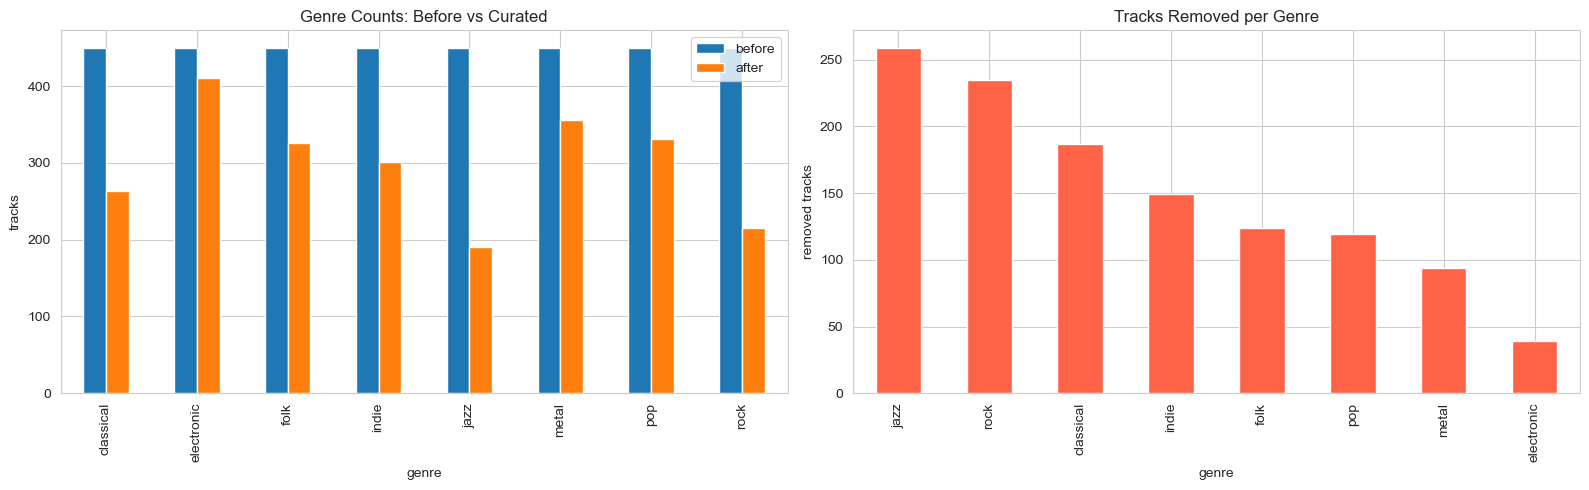

In [24]:
before_counts = base_df['genre'].value_counts().sort_index()
after_counts = curated_df['genre'].value_counts().sort_index()
plot_df = pd.DataFrame({'before': before_counts, 'after': after_counts}).fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
plot_df.sort_values('before', ascending=False).plot(kind='bar', ax=axes[0])
axes[0].set_title('Genre Counts: Before vs Curated')
axes[0].set_xlabel('genre')
axes[0].set_ylabel('tracks')

removed_by_genre = (
    base_df['genre'].value_counts() - curated_df['genre'].value_counts().reindex(base_df['genre'].unique()).fillna(0)
).sort_values(ascending=False)
removed_by_genre.plot(kind='bar', ax=axes[1], color='tomato')
axes[1].set_title('Tracks Removed per Genre')
axes[1].set_xlabel('genre')
axes[1].set_ylabel('removed tracks')

plt.tight_layout()
plt.show()


## Next Integration Step

In `post_download_pipeline_full.ipynb`, set:
- `RAW_METADATA_CSV` to the desired source if needed,
- `CLEAN_METADATA_CSV` to `data/processed/metadata_curated.csv`,
- `SPLITS_DIR` to `data/splits/curated`.

Then run training/evaluation with the curated set and compare macro F1 against the current baseline.
